# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2, transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Transformers ─────────────────────────────────────────
from transformers import AutoTokenizer, AutoModel, AlbertModel, AlbertTokenizer, BertTokenizer

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [ ]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1.3 Configuration

In [ ]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights"
RAW_DATA_FILE = "data/drugscom_plus_ai_labels.csv"
OUTPUT_DIR = "outputs_text_only"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"

TEXT_COLUMN = "review"

# ── 3-class sentiment ────────────────────────────────────
CLASS_NAMES = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Aspect config ────────────────────────────────────────
ASPECT_COLS = ["ai_efficacy", "ai_safety", "ai_burden", "ai_cost"]
ASPECT_WEIGHTS = {
    "ai_efficacy": 1.0,
    "ai_safety":   1.0,
    "ai_burden":   1.0,
    "ai_cost":     1.0,
}
POLARITY_MAP = {"POSITIVE": 1, "NEUTRAL": 0, "NEGATIVE": -1}

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 2

# ── A100 optimizations ──────────────────────────────────
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
print(f"BF16: {USE_BF16}")

# ── Retrain flag ─────────────────────────────────────────
RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_soft3class.pth",
        "params": OUTPUT_PATH / "best_albert_soft3class_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_soft3class.pth",
        "params": OUTPUT_PATH / "best_biobert_soft3class_params.json",
    },
}

print("--- R1 3-Class Soft-Label Configuration (Uniform 1:1:1:1) ---")
print(f"  Project    : {DRIVE_PROJECT_PATH}")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Aspect wts : {ASPECT_WEIGHTS}")


BF16: True
--- R1 3-Class Soft-Label Configuration (Uniform 1:1:1:1) ---
  Project    : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights
  Classes    : ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
  Aspect wts : {'ai_efficacy': 1.0, 'ai_safety': 1.0, 'ai_burden': 1.0, 'ai_cost': 1.0}


## 1.4 Mount drive & Load the data

In [ ]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0).reset_index()
print(f"Loaded {df_raw.shape[0]} rows.")

Mounted at /content/drive/
Loaded 102061 rows.


In [ ]:
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)

# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [ ]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


### 2.1.2 Validate aspect labels & derive 3-class soft labels


Validating aspect labels...
  ai_efficacy: {'POSITIVE': 66326, 'NEGATIVE': 27971, 'NEUTRAL': 7764}
  ai_safety: {'NEGATIVE': 40703, 'NEUTRAL': 34519, 'POSITIVE': 26839}
  ai_burden: {'NEUTRAL': 54537, 'NEGATIVE': 34262, 'POSITIVE': 13262}
  ai_cost: {'NEUTRAL': 92376, 'NEGATIVE': 6474, 'POSITIVE': 3211}

Deriving 3-class soft labels from aspect votes (1111 weights)...

3-class hard label distribution (argmax of soft):
y_hard_3class_name
NEUTRAL     54467
NEGATIVE    35057
POSITIVE    12537
Name: count, dtype: int64


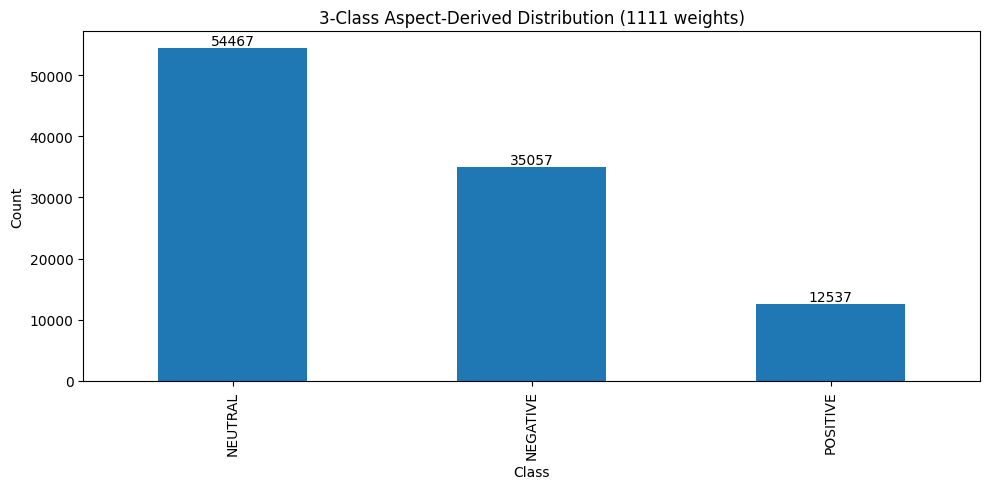


Entropy analysis:
NEGATIVE   | n=35057 | own_prob=0.654 | entropy=0.657
NEUTRAL    | n=54467 | own_prob=0.626 | entropy=0.684
POSITIVE   | n=12537 | own_prob=0.739 | entropy=0.575


In [ ]:
print("\nValidating aspect labels...")
for asp in ASPECT_COLS:
    if asp not in df_clean.columns:
        raise ValueError(f"Missing column: {asp}")
    df_clean[asp] = df_clean[asp].str.upper().str.strip()
    df_clean[asp] = df_clean[asp].replace({
        "VERY_POSITIVE": "POSITIVE",
        "VERY_NEGATIVE": "NEGATIVE",
    })
    valid_mask = df_clean[asp].isin(["POSITIVE", "NEUTRAL", "NEGATIVE"])
    n_invalid = (~valid_mask).sum()
    if n_invalid > 0:
        print(f"  WARNING: {asp} has {n_invalid} invalid values — setting to NEUTRAL")
        df_clean.loc[~valid_mask, asp] = "NEUTRAL"
    print(f"  {asp}: {df_clean[asp].value_counts().to_dict()}")

# ── Derive 3-class soft labels from aspect votes ────────
print("\nDeriving 3-class soft labels from aspect votes (1111 weights)...")

soft_3class = np.zeros((len(df_clean), 3), dtype=np.float32)  # [NEG, NEU, POS]

for asp in ASPECT_COLS:
    w = ASPECT_WEIGHTS[asp]
    neg_mask = (df_clean[asp] == "NEGATIVE").values
    neu_mask = (df_clean[asp] == "NEUTRAL").values
    pos_mask = (df_clean[asp] == "POSITIVE").values
    soft_3class[neg_mask, 0] += w
    soft_3class[neu_mask, 1] += w
    soft_3class[pos_mask, 2] += w

# Normalize rows to sum to 1
row_sums = soft_3class.sum(axis=1, keepdims=True)
soft_3class = soft_3class / np.clip(row_sums, 1e-8, None)

df_clean["soft_neg"] = soft_3class[:, 0]
df_clean["soft_neu"] = soft_3class[:, 1]
df_clean["soft_pos"] = soft_3class[:, 2]

# Hard label from soft (for stratification & evaluation)
df_clean["y_hard_3class"] = soft_3class.argmax(axis=1)
df_clean["y_hard_3class_name"] = df_clean["y_hard_3class"].map(
    {i: CLASS_NAMES[i] for i in range(NUM_CLASSES)}
)

print("\n3-class hard label distribution (argmax of soft):")
print(df_clean["y_hard_3class_name"].value_counts())

# Distribution plot
plt.figure(figsize=(10, 5))
counts = df_clean["y_hard_3class_name"].value_counts()
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("3-Class Aspect-Derived Distribution (1111 weights)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Entropy analysis
hard = soft_3class.argmax(axis=1)
print("\nEntropy analysis:")
for i, name in enumerate(CLASS_NAMES):
    mask = (hard == i)
    if mask.sum() == 0:
        continue
    class_soft = soft_3class[mask]
    own_prob = class_soft[:, i].mean()
    entropy = -(class_soft * np.log(np.clip(class_soft, 1e-8, 1))).sum(axis=1).mean()
    print(f"{name:10s} | n={mask.sum():5d} | own_prob={own_prob:.3f} | entropy={entropy:.3f}")


## 2.2 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y_for_split = df_clean["y_hard_3class"]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval["y_hard_3class"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_soft3class.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved master split → {split_path}")


Split counts:
split
train    61309
test     20383
val      20369
Name: count, dtype: int64
Leakage check passed.
Saved master split → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/master_split_soft3class.csv


# 3. ALBERT & BioBERT Models (soft training/validation/testing)


## 3.1 Shared helper functions

In [ ]:
def bootstrap_ci_mean(values: np.ndarray, n_iterations: int = 1000) -> Tuple[float, float, float]:
    """Bootstrap CI for the MEAN of a per-sample metric array."""
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    idx_all = np.arange(n)
    boot_means = []
    for _ in range(n_iterations):
        idx = resample(idx_all)
        boot_means.append(values[idx].mean())
    boot_means = np.asarray(boot_means, dtype=np.float64)
    return float(values.mean()), float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))


def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx],
                              average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


# ── Soft metrics ─────────────────────────────────────────

def per_sample_soft_ce(probs_np, soft_targets_np, eps=1e-12):
    """Per-sample Soft CE: -sum_k soft_k * log(p_k)"""
    probs = np.clip(np.asarray(probs_np, dtype=np.float64), eps, 1.0)
    soft = np.asarray(soft_targets_np, dtype=np.float64)
    return -np.sum(soft * np.log(probs), axis=1)


def per_sample_brier(probs_np, soft_targets_np):
    """Per-sample multiclass Brier: sum_k (p_k - soft_k)^2"""
    probs = np.asarray(probs_np, dtype=np.float64)
    soft = np.asarray(soft_targets_np, dtype=np.float64)
    return np.sum((probs - soft) ** 2, axis=1)


def bootstrap_soft_ce_ci(probs_np, soft_targets_np, n_iterations=1000):
    values = per_sample_soft_ce(probs_np, soft_targets_np)
    return bootstrap_ci_mean(values, n_iterations=n_iterations)


def bootstrap_brier_ci(probs_np, soft_targets_np, n_iterations=1000):
    values = per_sample_brier(probs_np, soft_targets_np)
    return bootstrap_ci_mean(values, n_iterations=n_iterations)


# ── Plots ────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, class_names, title="Model", save_dir=None):
    y_true_bin = label_binarize(np.asarray(y_true, dtype=int),
                                classes=np.arange(len(class_names)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", len(class_names))
    plt.figure(figsize=(10, 8))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{name} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


# ── High-level evaluators ────────────────────────────────

def evaluate_hard(y_true_hard, logits_np, class_names, model_tag="MODEL",
                  save_dir=None, n_boot=1000):
    """Hard evaluation: classification report + F1 CI + AUC CI + plots."""
    y_true_hard = np.asarray(y_true_hard, dtype=np.int64)
    probs = torch.softmax(torch.tensor(logits_np, dtype=torch.float32), dim=1).numpy()
    preds = probs.argmax(axis=1)

    print(f"\n{'='*60}")
    print(f"Evaluation (HARD): {model_tag}")
    print(f"{'='*60}")
    print(classification_report(
        y_true_hard, preds,
        labels=list(range(len(class_names))),
        target_names=class_names, digits=4, zero_division=0,
    ))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_true_hard, preds, n_iterations=n_boot)
    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_true_hard, probs, n_iterations=n_boot)

    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")
    print(f"Macro AUC:   {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_confusion_matrix(y_true_hard, preds, class_names,
                          title=f"{model_tag}_Soft3Class", save_dir=save_dir)
    plot_multiclass_roc(y_true_hard, probs, class_names,
                        title=f"{model_tag}_Soft3Class", save_dir=save_dir)

    return {
        "y_true": y_true_hard, "y_pred": preds, "y_prob": probs,
        "f1_weighted": f1_m, "f1_ci": (f1_lo, f1_hi),
        "auc_macro": auc_m, "auc_ci": (auc_lo, auc_hi),
    }


def evaluate_soft(probs_np, y_true_soft, model_tag="MODEL", n_boot=1000):
    """Soft evaluation: CE + Brier with bootstrap CIs."""
    probs_np = np.asarray(probs_np, dtype=np.float64)
    y_true_soft = np.asarray(y_true_soft, dtype=np.float64)

    ce_m, ce_lo, ce_hi = bootstrap_soft_ce_ci(probs_np, y_true_soft, n_iterations=n_boot)
    br_m, br_lo, br_hi = bootstrap_brier_ci(probs_np, y_true_soft, n_iterations=n_boot)

    print(f"\n--- Evaluation (SOFT): {model_tag} ---")
    print(f"Soft CE: {ce_m:.6f}  95% CI [{ce_lo:.6f}, {ce_hi:.6f}]")
    print(f"Brier:   {br_m:.6f}  95% CI [{br_lo:.6f}, {br_hi:.6f}]")

    return {
        "soft_ce": ce_m, "soft_ce_ci": (ce_lo, ce_hi),
        "brier": br_m, "brier_ci": (br_lo, br_hi),
    }


## 3.2 Data splits & labels

In [ ]:
SOFT_3CLASS_COLS = ["soft_neg", "soft_neu", "soft_pos"]

def _extract_soft_3class(df):
    s = df[SOFT_3CLASS_COLS].to_numpy(dtype=np.float32)
    return s / np.clip(s.sum(axis=1, keepdims=True), 1e-8, None)


df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Soft labels for all splits (training uses soft, val/test use both)
y_train_soft = _extract_soft_3class(df_train)
y_val_soft   = _extract_soft_3class(df_val)
y_test_soft  = _extract_soft_3class(df_test)

# Hard labels (argmax) for evaluation
y_train_hard = y_train_soft.argmax(axis=1).astype(np.int64)
y_val_hard   = y_val_soft.argmax(axis=1).astype(np.int64)
y_test_hard  = y_test_soft.argmax(axis=1).astype(np.int64)

print(f"Train soft: {y_train_soft.shape} | Val soft: {y_val_soft.shape} | Test soft: {y_test_soft.shape}")
print(f"Val  hard dist: {np.bincount(y_val_hard, minlength=NUM_CLASSES)}")
print(f"Test hard dist: {np.bincount(y_test_hard, minlength=NUM_CLASSES)}")

Train soft: (61309, 3) | Val soft: (20369, 3) | Test soft: (20383, 3)
Val  hard dist: [ 6915 10867  2587]
Test hard dist: [ 6970 10940  2473]


## 3.3 Generic soft-label model componets

In [ ]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Dataset ──────────────────────────────────────────────
class SoftLabelDataset(Dataset):
    """Pre-tokenized dataset with optional soft and hard labels."""

    def __init__(self, input_ids, attention_masks,
                 hard_labels=None, soft_labels=None):
        self.input_ids = input_ids
        self.attention_masks = attention_masks

        self.soft_labels = None
        if soft_labels is not None:
            sl = np.asarray(soft_labels, dtype=np.float32)
            rs = sl.sum(axis=1, keepdims=True)
            self.soft_labels = sl / np.clip(rs, 1e-8, None)

        self.hard_labels = None
        if hard_labels is not None:
            self.hard_labels = np.asarray(hard_labels, dtype=np.int64)
        elif self.soft_labels is not None:
            self.hard_labels = self.soft_labels.argmax(axis=1).astype(np.int64)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        if self.hard_labels is not None:
            item["labels"] = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        if self.soft_labels is not None:
            item["soft_labels"] = torch.tensor(self.soft_labels[idx], dtype=torch.float32)
        return item


# ── Classifier ───────────────────────────────────────────
class TransformerClassifier(nn.Module):
    """Base transformer → dropout → linear → logits (3-class)."""

    def __init__(self, base_model, hidden_size, num_classes=NUM_CLASSES,
                 dropout=0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls))


# ── Loss function ────────────────────────────────────────
def soft_cross_entropy(logits, soft_targets):
    """Soft-label CE: -sum_k soft_k * log_softmax(logits)_k"""
    log_probs = torch.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()


# ── Inference helper ─────────────────────────────────────
def predict_logits(model, loader, device=DEVICE):
    """Run inference, return (logits, hard_labels, soft_labels) as numpy."""
    model.eval()
    all_logits, all_labels, all_soft = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(ids, mask)

            all_logits.append(logits.float().cpu().numpy())
            if "labels" in batch:
                all_labels.append(batch["labels"].numpy())
            if "soft_labels" in batch:
                all_soft.append(batch["soft_labels"].numpy())
    return (
        np.concatenate(all_logits),
        np.concatenate(all_labels) if all_labels else None,
        np.concatenate(all_soft) if all_soft else None,
    )


# ── Training function ────────────────────────────────────
def train_soft_model(model, train_loader, val_loader,
                     lr=2e-5, max_epochs=6, patience=PATIENCE):
    """Train with soft CE + BF16 autocast.
    Best epoch selected by val weighted F1. Early stopping."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_f1, best_state, best_epoch = -1.0, None, -1
    best_val_soft_loss = np.inf
    no_improve = 0

    history = {"train_soft_loss": [], "val_soft_loss": [], "val_f1w": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            soft = batch["soft_labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(ids, mask)
                loss = soft_cross_entropy(logits, soft)

            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = float(np.mean(losses))

        # Validate
        model.eval()
        val_preds, val_true, val_losses_ep = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    logits = model(ids, mask)

                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["labels"].numpy())

                # Soft loss for monitoring
                if "soft_labels" in batch:
                    soft = batch["soft_labels"].to(DEVICE, non_blocking=True)
                    with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                        vloss = soft_cross_entropy(logits, soft)
                    val_losses_ep.append(vloss.item())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_soft_loss = float(np.mean(val_losses_ep)) if val_losses_ep else np.nan

        history["train_soft_loss"].append(train_loss)
        history["val_soft_loss"].append(val_soft_loss)
        history["val_f1w"].append(val_f1)

        print(f"  Epoch {epoch}/{max_epochs} | TrainLoss={train_loss:.4f} | "
              f"ValSoftLoss={val_soft_loss:.4f} | ValF1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            best_val_soft_loss = val_soft_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model, best_epoch, history


def build_loaders(tokenizer, model_label, include_val_soft=True):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True)

    # Train: soft labels for training
    train_loader = DataLoader(
        SoftLabelDataset(train_ids, train_masks, soft_labels=y_train_soft),
        shuffle=True, **loader_kw)

    # Val: both soft (for soft loss monitoring) and hard (for F1)
    val_loader = DataLoader(
        SoftLabelDataset(val_ids, val_masks,
                         soft_labels=y_val_soft if include_val_soft else None,
                         hard_labels=y_val_hard),
        shuffle=False, **loader_kw)

    # Test: both soft and hard for full evaluation
    test_loader = DataLoader(
        SoftLabelDataset(test_ids, test_masks,
                         soft_labels=y_test_soft,
                         hard_labels=y_test_hard),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader

## 3.4 ALBERT

In [ ]:
print("\n" + "=" * 60)
print("ALBERT — 3-Class Soft-Label Training (1111)")
print("=" * 60)


ALBERT — 3-Class Soft-Label Training (1111)


### 3.4.1 Pre-tokenize

In [ ]:
albert_tokenizer = AlbertTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [ ]:
if RETRAIN:
    set_seed()
    start = time.time()

    param_space = {
        "lr":      (np.log10(1e-5), np.log10(3e-5)),
        "epochs":  (6, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Soft 3-Class"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
        model = TransformerClassifier(
            base, base.config.hidden_size,
            num_classes=NUM_CLASSES, dropout=hp["dropout"],
        )

        f1_val, model, best_ep, history = train_soft_model(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
    best_albert = TransformerClassifier(
        base, base.config.hidden_size,
        num_classes=NUM_CLASSES,
        dropout=best_params_albert.get("dropout", 0.1),
    )
    best_albert.load_state_dict(
        torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE)
    )

best_albert.to(DEVICE)
best_albert.eval()


ALBERT Soft 3-Class:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | TrainLoss=0.8986 | ValSoftLoss=0.8244 | ValF1=0.6856
  Epoch 2/9 | TrainLoss=0.8061 | ValSoftLoss=0.8093 | ValF1=0.7673
  Epoch 3/9 | TrainLoss=0.7825 | ValSoftLoss=0.8072 | ValF1=0.7772
  Epoch 4/9 | TrainLoss=0.7650 | ValSoftLoss=0.8095 | ValF1=0.7690
  Epoch 5/9 | TrainLoss=0.7521 | ValSoftLoss=0.8109 | ValF1=0.7570
  Epoch 6/9 | TrainLoss=0.7391 | ValSoftLoss=0.8222 | ValF1=0.7550
  Early stopping at epoch 6.


ALBERT Soft 3-Class: 100%|██████████| 10/10 [1:53:51<00:00, 683.15s/it]

ALBERT tuning: 6831.5s | Best F1=0.7772
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.22900784668310975}


TransformerClassifier(
  (base): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0, inplace=False)
                (output_dropout): Dropout(p=0, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Line

### 3.4.3 Model evaluation


Evaluation (HARD): ALBERT_TEST
              precision    recall  f1-score   support

    NEGATIVE     0.8572    0.8270    0.8418      6970
     NEUTRAL     0.8071    0.7910    0.7989     10940
    POSITIVE     0.5106    0.6066    0.5544      2473

    accuracy                         0.7809     20383
   macro avg     0.7250    0.7415    0.7317     20383
weighted avg     0.7883    0.7809    0.7839     20383

Weighted F1: 0.7841  95% CI [0.7788, 0.7896]
Macro AUC:   0.9066  95% CI [0.9033, 0.9102]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/ALBERT_TEST_Soft3Class_confusion_matrix.png


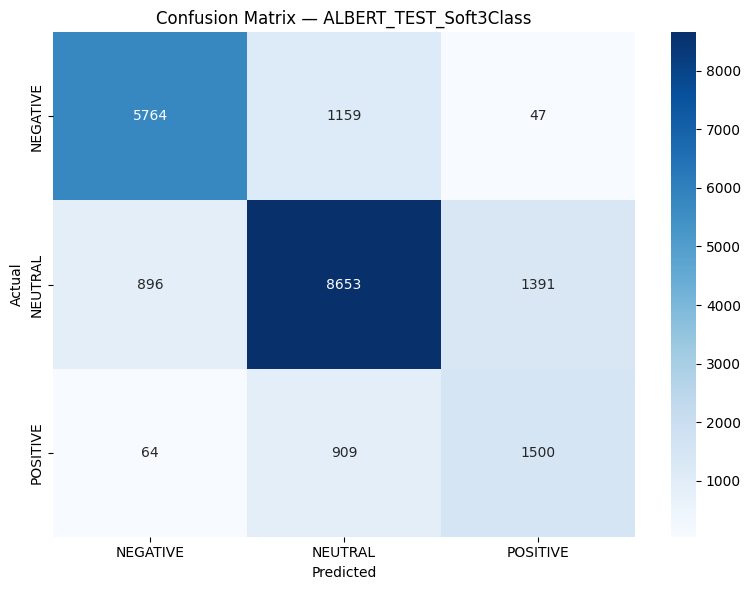

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/ALBERT_TEST_Soft3Class_roc_curve.png


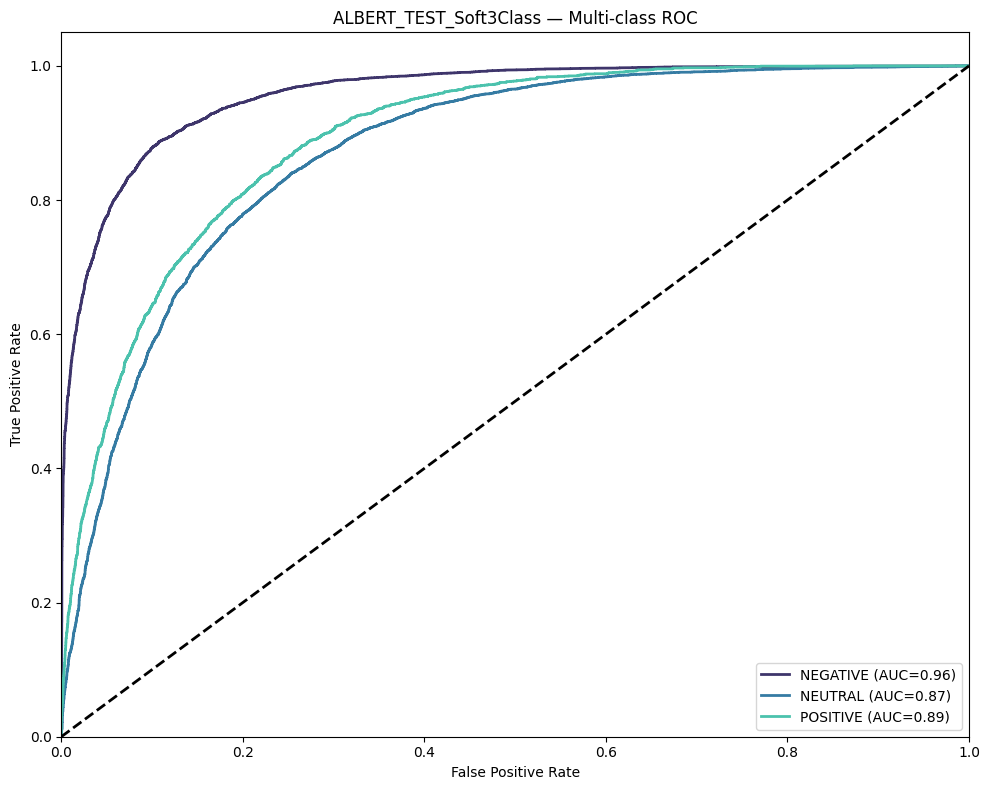


--- Evaluation (SOFT): ALBERT_TEST ---
Soft CE: 0.811629  95% CI [0.807676, 0.815311]
Brier:   0.073837  95% CI [0.072384, 0.075312]

Evaluation (HARD): ALBERT_VAL
              precision    recall  f1-score   support

    NEGATIVE     0.8634    0.8336    0.8482      6915
     NEUTRAL     0.7998    0.7829    0.7913     10867
    POSITIVE     0.4879    0.5763    0.5284      2587

    accuracy                         0.7739     20369
   macro avg     0.7170    0.7309    0.7226     20369
weighted avg     0.7818    0.7739    0.7772     20369

Weighted F1: 0.7773  95% CI [0.7717, 0.7831]
Macro AUC:   0.9022  95% CI [0.8988, 0.9055]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/ALBERT_VAL_Soft3Class_confusion_matrix.png


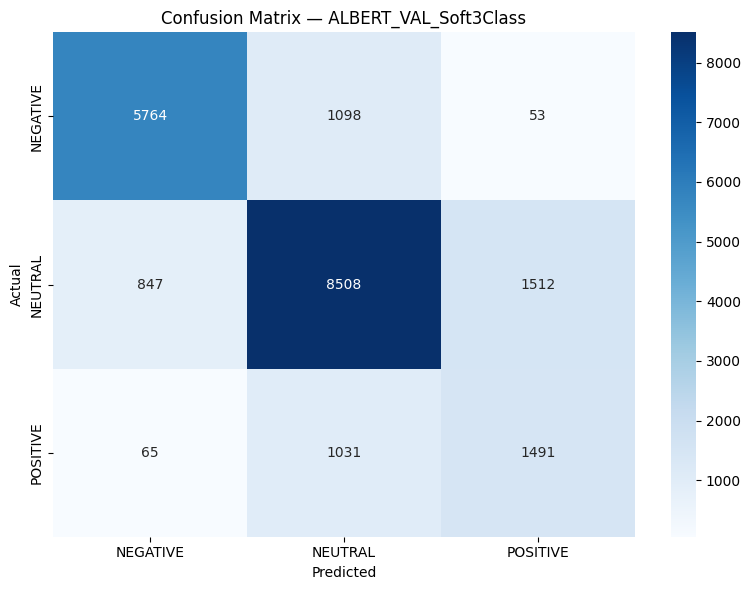

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/ALBERT_VAL_Soft3Class_roc_curve.png


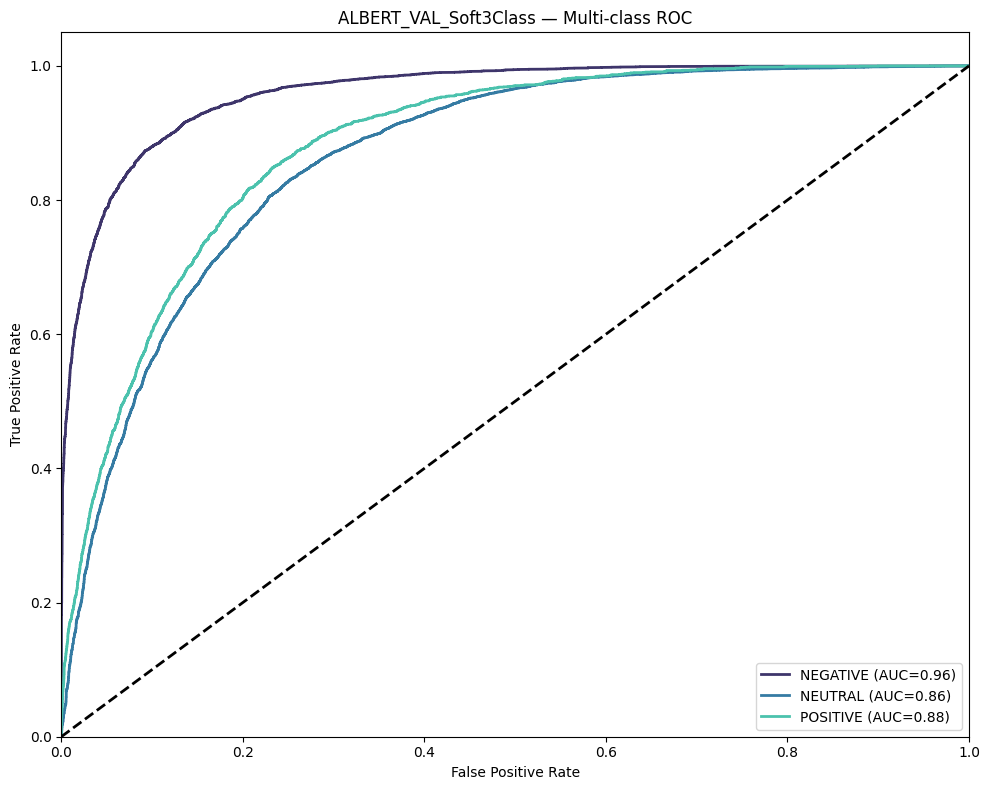


--- Evaluation (SOFT): ALBERT_VAL ---
Soft CE: 0.807663  95% CI [0.803869, 0.811483]
Brier:   0.073557  95% CI [0.072180, 0.074945]


In [ ]:
# Hard evaluation
test_logits_a, test_y_hard_a, test_y_soft_a = predict_logits(
    best_albert, test_loader_albert, DEVICE)
test_probs_a = torch.softmax(torch.tensor(test_logits_a), dim=1).numpy()

albert_hard_results = evaluate_hard(
    test_y_hard_a, test_logits_a, CLASS_NAMES,
    model_tag="ALBERT_TEST", save_dir=str(OUTPUT_PATH))

# Soft evaluation
albert_soft_results = evaluate_soft(
    test_probs_a, test_y_soft_a, model_tag="ALBERT_TEST")

# Val evaluation (for comparison)
val_logits_a, val_y_hard_a, val_y_soft_a = predict_logits(
    best_albert, val_loader_albert, DEVICE)
val_probs_a = torch.softmax(torch.tensor(val_logits_a), dim=1).numpy()

albert_val_hard = evaluate_hard(
    val_y_hard_a, val_logits_a, CLASS_NAMES,
    model_tag="ALBERT_VAL", save_dir=str(OUTPUT_PATH))
albert_val_soft = evaluate_soft(
    val_probs_a, val_y_soft_a, model_tag="ALBERT_VAL")

## 3.5 BioBERT

In [ ]:
print("\n" + "=" * 60)
print("BioBERT — 3-Class Soft-Label Training (1111)")
print("=" * 60)


BioBERT — 3-Class Soft-Label Training (1111)


### 3.5.1 Pre-tokenize

In [ ]:
biobert_tokenizer = BertTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

vocab.txt: 0.00B [00:00, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [ ]:
if RETRAIN:
    set_seed()
    start = time.time()

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Soft 3-Class"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
        model = TransformerClassifier(
            base, base.config.hidden_size,
            num_classes=NUM_CLASSES, dropout=hp["dropout"],
        )

        f1_val, model, best_ep, history = train_soft_model(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
    best_biobert = TransformerClassifier(
        base, base.config.hidden_size,
        num_classes=NUM_CLASSES,
        dropout=best_params_biobert.get("dropout", 0.1),
    )
    best_biobert.load_state_dict(
        torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE)
    )

best_biobert.to(DEVICE)
best_biobert.eval()

BioBERT Soft 3-Class:   0%|          | 0/10 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | TrainLoss=0.8664 | ValSoftLoss=0.8237 | ValF1=0.7143
  Epoch 2/9 | TrainLoss=0.8040 | ValSoftLoss=0.8111 | ValF1=0.7539
  Epoch 3/9 | TrainLoss=0.7799 | ValSoftLoss=0.8127 | ValF1=0.7574
  Epoch 4/9 | TrainLoss=0.7602 | ValSoftLoss=0.8157 | ValF1=0.7698
  Epoch 5/9 | TrainLoss=0.7460 | ValSoftLoss=0.8223 | ValF1=0.7579
  Epoch 6/9 | TrainLoss=0.7336 | ValSoftLoss=0.8378 | ValF1=0.7512
  Epoch 7/9 | TrainLoss=0.7229 | ValSoftLoss=0.8366 | ValF1=0.7535
  Early stopping at epoch 7.


BioBERT Soft 3-Class: 100%|██████████| 10/10 [57:30<00:00, 345.07s/it]

BioBERT tuning: 3450.7s | Best F1=0.7745
Best params: {'lr': 1.160497696239576e-05, 'epochs': 8, 'dropout': 0.08535068283342875}


TransformerClassifier(
  (base): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

### 3.4.3 Model evaluation


Evaluation (HARD): BioBERT_TEST
              precision    recall  f1-score   support

    NEGATIVE     0.8734    0.7802    0.8242      6970
     NEUTRAL     0.7867    0.8152    0.8007     10940
    POSITIVE     0.5133    0.5855    0.5470      2473

    accuracy                         0.7754     20383
   macro avg     0.7245    0.7270    0.7240     20383
weighted avg     0.7832    0.7754    0.7779     20383

Weighted F1: 0.7780  95% CI [0.7727, 0.7832]
Macro AUC:   0.9001  95% CI [0.8967, 0.9035]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/BioBERT_TEST_Soft3Class_confusion_matrix.png


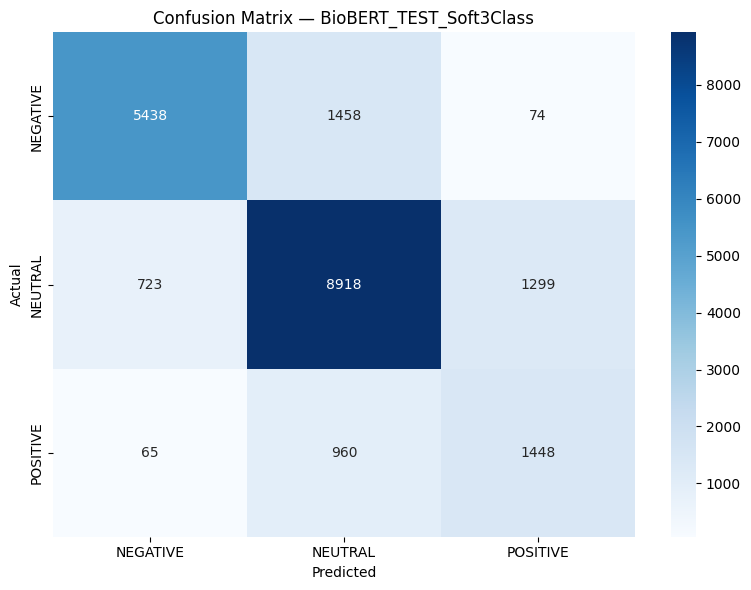

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/BioBERT_TEST_Soft3Class_roc_curve.png


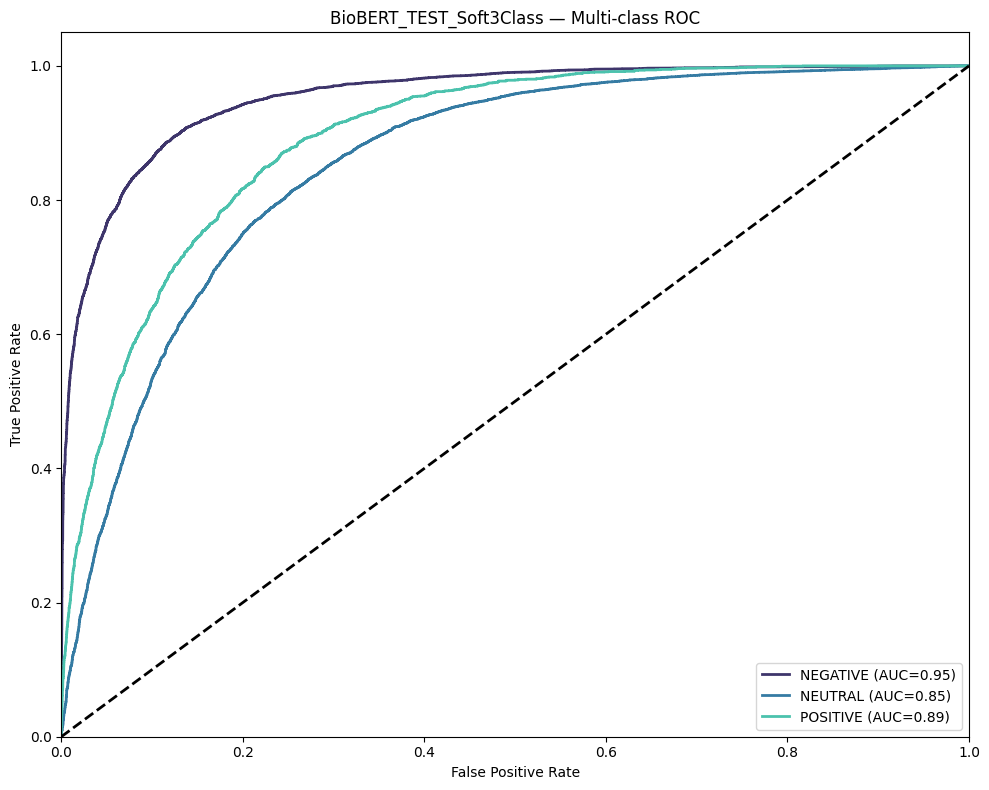


--- Evaluation (SOFT): BioBERT_TEST ---
Soft CE: 0.817881  95% CI [0.813743, 0.821741]
Brier:   0.075575  95% CI [0.074064, 0.077022]

Evaluation (HARD): BioBERT_VAL
              precision    recall  f1-score   support

    NEGATIVE     0.8756    0.7851    0.8279      6915
     NEUTRAL     0.7818    0.8165    0.7988     10867
    POSITIVE     0.5080    0.5535    0.5298      2587

    accuracy                         0.7724     20369
   macro avg     0.7218    0.7184    0.7188     20369
weighted avg     0.7789    0.7724    0.7745     20369

Weighted F1: 0.7745  95% CI [0.7681, 0.7804]
Macro AUC:   0.8971  95% CI [0.8937, 0.9006]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/BioBERT_VAL_Soft3Class_confusion_matrix.png


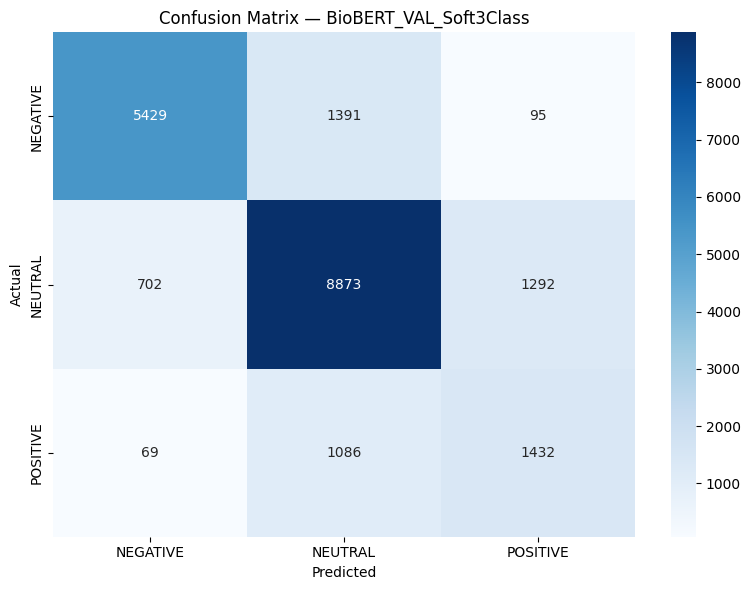

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/BioBERT_VAL_Soft3Class_roc_curve.png


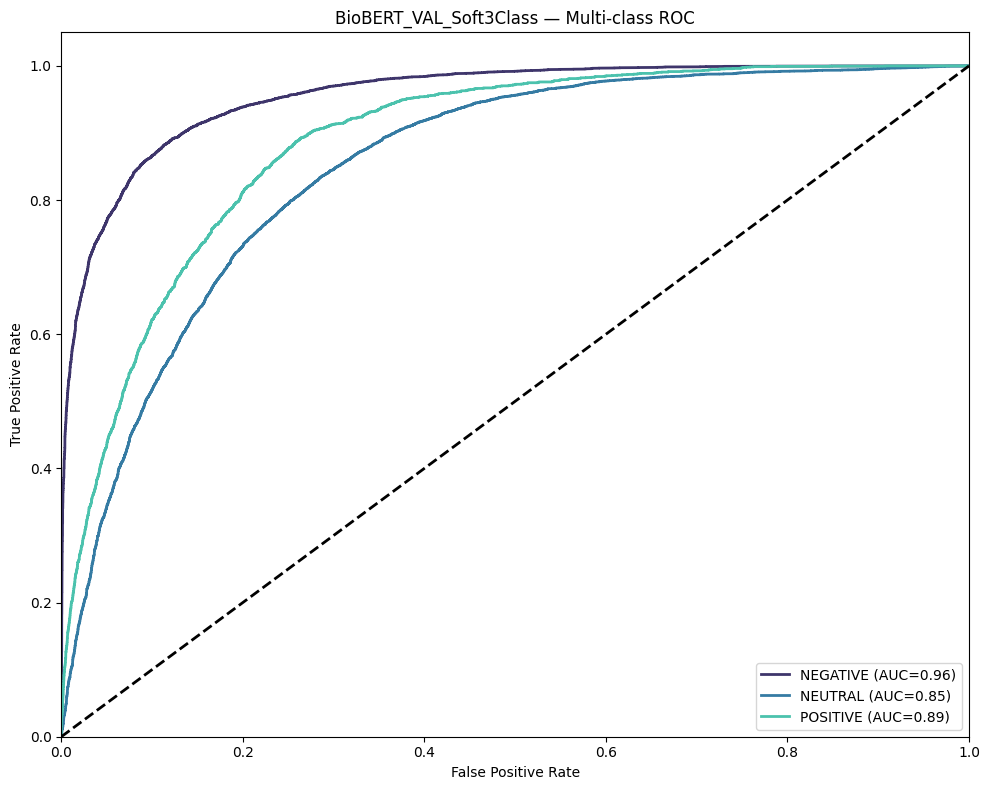


--- Evaluation (SOFT): BioBERT_VAL ---
Soft CE: 0.814073  95% CI [0.809820, 0.818165]
Brier:   0.075788  95% CI [0.074346, 0.077245]


In [ ]:
# Hard evaluation
test_logits_b, test_y_hard_b, test_y_soft_b = predict_logits(
    best_biobert, test_loader_biobert, DEVICE)
test_probs_b = torch.softmax(torch.tensor(test_logits_b), dim=1).numpy()

biobert_hard_results = evaluate_hard(
    test_y_hard_b, test_logits_b, CLASS_NAMES,
    model_tag="BioBERT_TEST", save_dir=str(OUTPUT_PATH))

# Soft evaluation
biobert_soft_results = evaluate_soft(
    test_probs_b, test_y_soft_b, model_tag="BioBERT_TEST")

# Val evaluation
val_logits_b, val_y_hard_b, val_y_soft_b = predict_logits(
    best_biobert, val_loader_biobert, DEVICE)
val_probs_b = torch.softmax(torch.tensor(val_logits_b), dim=1).numpy()

biobert_val_hard = evaluate_hard(
    val_y_hard_b, val_logits_b, CLASS_NAMES,
    model_tag="BioBERT_VAL", save_dir=str(OUTPUT_PATH))
biobert_val_soft = evaluate_soft(
    val_probs_b, val_y_soft_b, model_tag="BioBERT_VAL")

## 3.6 Save prediction

In [ ]:
df_test_out = df_test[[TEXT_COLUMN, "y_hard_3class"]].copy()
df_test_out["albert_pred"] = albert_hard_results["y_pred"]
df_test_out["biobert_pred"] = biobert_hard_results["y_pred"]

for i, name in enumerate(CLASS_NAMES):
    df_test_out[f"albert_p_{name}"] = albert_hard_results["y_prob"][:, i]
    df_test_out[f"biobert_p_{name}"] = biobert_hard_results["y_prob"][:, i]

pred_path = OUTPUT_PATH / "test_predictions_soft3class.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

# ── Summary ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — 3-Class Soft-Label (1111 aspect weights)")
print("=" * 60)

for model_name, hard_r, soft_r in [
    ("ALBERT", albert_hard_results, albert_soft_results),
    ("BioBERT", biobert_hard_results, biobert_soft_results),
]:
    print(f"\n{model_name}:")
    print(f"  Weighted F1: {hard_r['f1_weighted']:.4f} "
          f"[{hard_r['f1_ci'][0]:.4f}, {hard_r['f1_ci'][1]:.4f}]")
    print(f"  Macro AUC:   {hard_r['auc_macro']:.4f} "
          f"[{hard_r['auc_ci'][0]:.4f}, {hard_r['auc_ci'][1]:.4f}]")
    print(f"  Soft CE:     {soft_r['soft_ce']:.6f} "
          f"[{soft_r['soft_ce_ci'][0]:.6f}, {soft_r['soft_ce_ci'][1]:.6f}]")
    print(f"  Brier:       {soft_r['brier']:.6f} "
          f"[{soft_r['brier_ci'][0]:.6f}, {soft_r['brier_ci'][1]:.6f}]")


Saved predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only/test_predictions_soft3class.csv

SUMMARY — 3-Class Soft-Label (1111 aspect weights)

ALBERT:
  Weighted F1: 0.7841 [0.7788, 0.7896]
  Macro AUC:   0.9066 [0.9033, 0.9102]
  Soft CE:     0.811629 [0.807676, 0.815311]
  Brier:       0.073837 [0.072384, 0.075312]

BioBERT:
  Weighted F1: 0.7780 [0.7727, 0.7832]
  Macro AUC:   0.9001 [0.8967, 0.9035]
  Soft CE:     0.817881 [0.813743, 0.821741]
  Brier:       0.075575 [0.074064, 0.077022]
